In [1]:
from datasets import load_dataset
import torch
from torch import nn
import torchvision
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

print(f"PyTorch: {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")

/home/uno21/.virtualenvs/traffic-sign-cnn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128


In [2]:
ds = load_dataset("tanganke/gtsrb")
print(ds)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 26640
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 12630
    })
    contrast: Dataset({
        features: ['image', 'label'],
        num_rows: 12630
    })
    gaussian_noise: Dataset({
        features: ['image', 'label'],
        num_rows: 12630
    })
    impulse_noise: Dataset({
        features: ['image', 'label'],
        num_rows: 12630
    })
    jpeg_compression: Dataset({
        features: ['image', 'label'],
        num_rows: 12630
    })
    motion_blur: Dataset({
        features: ['image', 'label'],
        num_rows: 12630
    })
    pixelate: Dataset({
        features: ['image', 'label'],
        num_rows: 12630
    })
    spatter: Dataset({
        features: ['image', 'label'],
        num_rows: 12630
    })
})


In [3]:
# Transforms
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.3337, 0.3064, 0.3171],
                         std=[0.2672, 0.2564, 0.2629])
])

transform_train = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.3337, 0.3064, 0.3171],
                         std=[0.2672, 0.2564, 0.2629])
])

In [4]:
# Dataset wrapper
class GTSRBDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.data = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx]['image'].convert('RGB')
        label = self.data[idx]['label']
        if self.transform:

            image = self.transform(image)
        return image, label

In [5]:
# Splits
full_train = GTSRBDataset(ds['train'], transform=transform_train)
test_dataset = GTSRBDataset(ds['test'], transform=transform)

train_size = int(0.8 * len(full_train))
val_size = len(full_train) - train_size
train_dataset, val_dataset = random_split(full_train, [train_size, val_size])

print(f"Train: {len(train_dataset)}")
print(f"Val: {len(val_dataset)}")
print(f"Test: {len(test_dataset)}")

Train: 21312
Val: 5328
Test: 12630


In [6]:
# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Batches en train: {len(train_loader)}")
print(f"Batches en val: {len(val_loader)}")
print(f"Batches en test: {len(test_loader)}")

Batches en train: 666
Batches en val: 167
Batches en test: 395


In [7]:
# Verificacion de datos
image, labels = next(iter(train_loader))
print(f"Shape del batch: {image.shape}")
print(f"Tipo: {image.dtype}")
print(f"Min: {image.min():.3f}, Max: {image.max():.3f}")
print(f"Labels shape: {labels.shape}")

Shape del batch: torch.Size([32, 3, 32, 32])
Tipo: torch.float32
Min: -1.249, Max: 2.705
Labels shape: torch.Size([32])


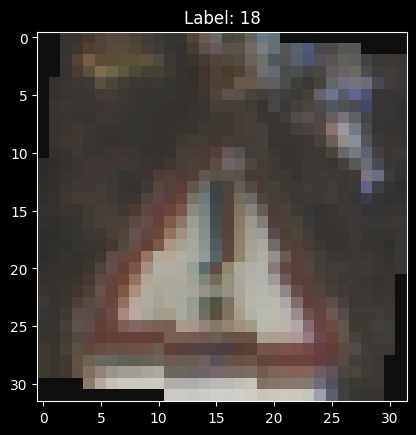

In [11]:
# Visualizacion de imagenes
img = image[0]
img = img.permute(1, 2, 0)  # CxHxW -> HxWxC
img = img * torch.tensor([0.2672, 0.2564, 0.2629]) + torch.tensor([0.3337, 0.3064, 0.3171])  # Desnormalizar
img = torch.clamp(img, 0, 1)
plt.imshow(img.numpy())
plt.title(f"Label: {labels[0].item()}")
plt.show()